# Walk-forward evaluation: LightGBM with expanding train window

Companion notebook to the walk-forward mode of
[src/training_pipeline.py](../src/training_pipeline.py).

Each *step* is a fresh retrain on every flight scheduled before the
step's boundary `T_i`, followed by 48-hour per-occasion scoring for
`t_issue ∈ [T_i, T_{i+1})`. The training window **grows** each step;
the test slice is the next `--retrain-every-days` of issue times. This
mirrors how the model would be retrained on a fixed cadence in
production.

The producer command was:

```bash
python -m src.training_pipeline --walk-forward --model lgbm \
    --retrain-every-days 30
```

Three artifacts feed this notebook:

| File | Granularity |
|---|---|
| `walkforward_step_metrics.csv`        | one row per retrain step |
| `walkforward_per_occasion.parquet`    | one row per (step, 6 h occasion) |
| `walkforward_per_flight.parquet`      | one row per (step, occasion, flight) |


## 1. Setup

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

ART = ROOT / "artifacts" / "disruption_model"
STEPS    = pd.read_csv(ART / "walkforward_step_metrics.csv",
                       parse_dates=["t_train_end", "t_test_start", "t_test_end"])
OCC      = pd.read_parquet(ART / "walkforward_per_occasion.parquet")
FLIGHT   = pd.read_parquet(ART / "walkforward_per_flight.parquet")

# single-shot baseline (HistGBT) for context, if present
SINGLE = None
single_metrics_path = ART / "metrics.json"
if single_metrics_path.exists():
    SINGLE = json.loads(single_metrics_path.read_text())

from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
)
from sklearn.calibration import calibration_curve

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.dpi"] = 110
print(f"{len(STEPS)} walk-forward steps loaded")


9 walk-forward steps loaded


## 2. Per-step summary

In [2]:
cols = ["step", "t_train_end", "n_train_rows", "n_occasions",
        "test_base_rate", "test_auc_roc", "test_auc_pr", "test_brier",
        "occ_mae", "occ_bias", "occ_pearson"]
STEPS[cols].set_index("step")


,t_train_end,n_train_rows,n_occasions,test_base_rate,test_auc_roc,test_auc_pr,test_brier,occ_mae,occ_bias,occ_pearson
step,,,,,,,,,,
0,2025-07-01 00:00:00+00:00,1160649,121,0.4340,0.7232,0.6716,0.2148,0.0809,-0.0671,0.6584
1,2025-07-31 00:00:00+00:00,1190246,121,0.3412,0.7187,0.5911,0.1938,0.0682,0.0236,0.8312
2,2025-08-30 00:00:00+00:00,1219727,121,0.2601,0.6739,0.3965,0.1796,0.0449,-0.0067,0.5221
3,2025-09-29 00:00:00+00:00,1249121,121,0.2902,0.6584,0.4230,0.1963,0.0584,-0.0499,0.6451
4,2025-10-29 00:00:00+00:00,1277752,121,0.3022,0.7009,0.5404,0.1867,0.0760,-0.0359,0.8587
5,2025-11-28 00:00:00+00:00,1308057,121,0.4681,0.7274,0.7059,0.2150,0.1064,-0.0603,0.8507
6,2025-12-28 00:00:00+00:00,1336752,121,0.4271,0.7553,0.7055,0.1974,0.0945,0.0170,0.8523
7,2026-01-27 00:00:00+00:00,1363652,121,0.3436,0.7130,0.5876,0.1961,0.0553,0.0369,0.9027
8,2026-02-26 00:00:00+00:00,1388495,13,0.2709,0.5756,0.3117,0.2041,0.0672,0.0536,0.0439


**`n_train_rows` should grow monotonically across steps** — that's the whole point of the expanding-window setup. **`test_base_rate`** is the disruption rate in each test slice — if it shifts a lot step-to-step, expect to see calibration drift below.

## 3. Metric trajectories over retrain steps

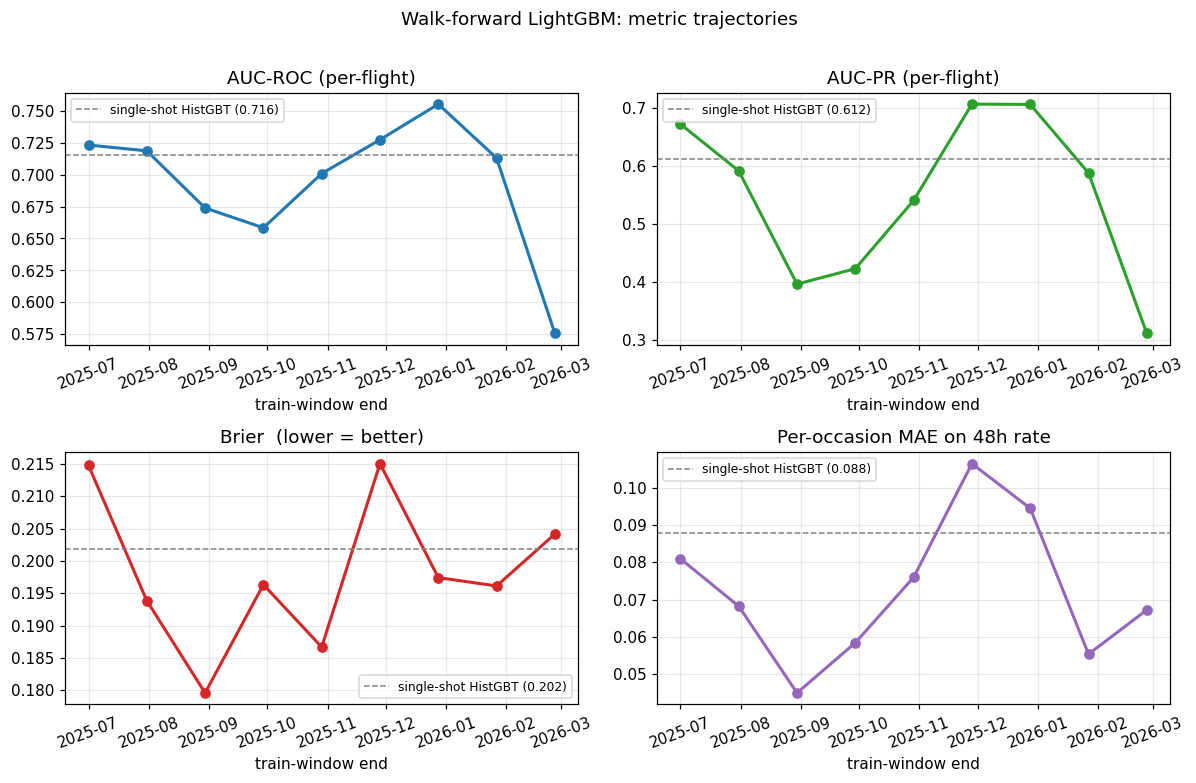

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
metric_panels = [
    ("test_auc_roc",  "AUC-ROC (per-flight)", "C0"),
    ("test_auc_pr",   "AUC-PR (per-flight)",  "C2"),
    ("test_brier",    "Brier  (lower = better)", "C3"),
    ("occ_mae",       "Per-occasion MAE on 48h rate", "C4"),
]
for ax, (col, title, color) in zip(axes.ravel(), metric_panels):
    ax.plot(STEPS["t_train_end"], STEPS[col], "o-", color=color, lw=2)
    if SINGLE is not None and col in SINGLE:
        ax.axhline(SINGLE[col], color="gray", ls="--", lw=1,
                   label=f"single-shot HistGBT ({SINGLE[col]:.3f})")
        ax.legend(fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("train-window end")
    ax.grid(alpha=0.3)
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(20)
fig.suptitle("Walk-forward LightGBM: metric trajectories", y=1.01)
plt.tight_layout(); plt.show()


Read the panels together: AUC / AUC-PR moving up across steps would suggest the model genuinely benefits from more recent data; Brier and per-occasion MAE moving down would say the same in calibration terms. **Per-occasion MAE is the deliverable**, so that's the panel to anchor on.

## 4. Calibration bias over steps

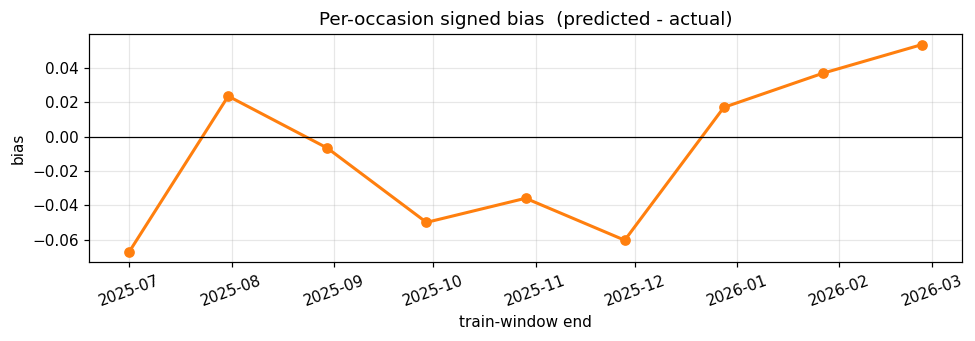

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(STEPS["t_train_end"], STEPS["occ_bias"], "o-", color="C1", lw=2)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Per-occasion signed bias  (predicted - actual)")
ax.set_xlabel("train-window end"); ax.set_ylabel("bias")
ax.grid(alpha=0.3)
for lbl in ax.get_xticklabels():
    lbl.set_rotation(20)
plt.tight_layout(); plt.show()


Negative bias = the model under-predicts the realised 48 h disruption rate. A drift toward zero across steps is what you'd hope to see if retraining is closing the regime gap; persistent negative bias would say the model class itself is mis-specified.

## 5. Per-step calibration plot

/var/folders/9y/nhtlk1191r78kf_7vfn0gm880000gn/T/ipykernel_49347/3739425421.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", len(STEPS))


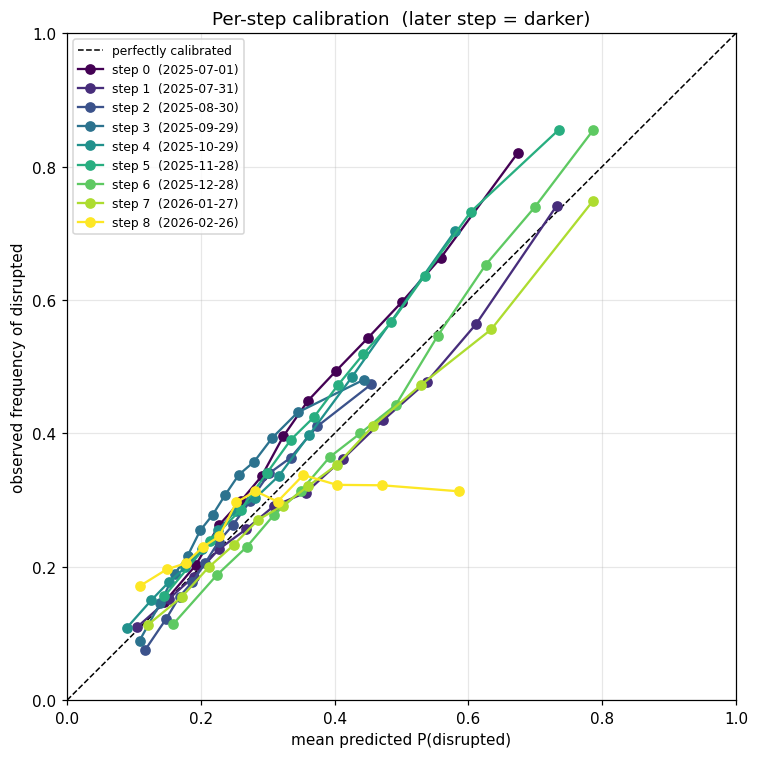

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")

cmap = cm.get_cmap("viridis", len(STEPS))
for i, row in STEPS.iterrows():
    sub = FLIGHT.loc[FLIGHT["step"] == row["step"]]
    if not len(sub): continue
    try:
        frac_pos, mean_pred = calibration_curve(
            sub["y_true"].to_numpy(),
            sub["p_hat"].to_numpy(),
            n_bins=12, strategy="quantile")
    except Exception as e:
        print(f"step {row['step']}: {e}"); continue
    ax.plot(mean_pred, frac_pos, "o-", color=cmap(i),
            label=f"step {int(row['step'])}  ({row['t_train_end'].date()})")

ax.set_xlabel("mean predicted P(disrupted)")
ax.set_ylabel("observed frequency of disrupted")
ax.set_title("Per-step calibration  (later step = darker)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()


Steps that hug the diagonal more tightly are better calibrated. If later steps converge toward the diagonal that's evidence the expanding train window is paying its way; if all the curves cluster together off-diagonal then the regime gap is something a different model-class change (or post-hoc isotonic recalibration) needs to address — retraining alone isn't doing it.

## 6. Distribution of per-occasion error across steps

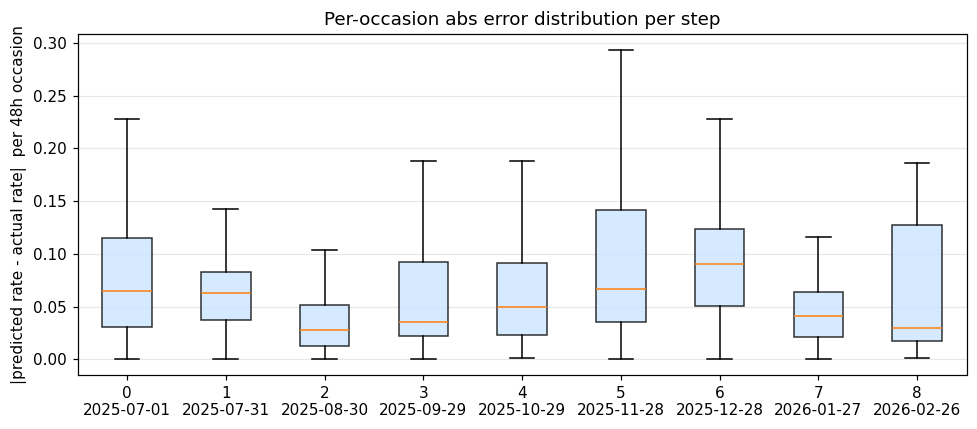

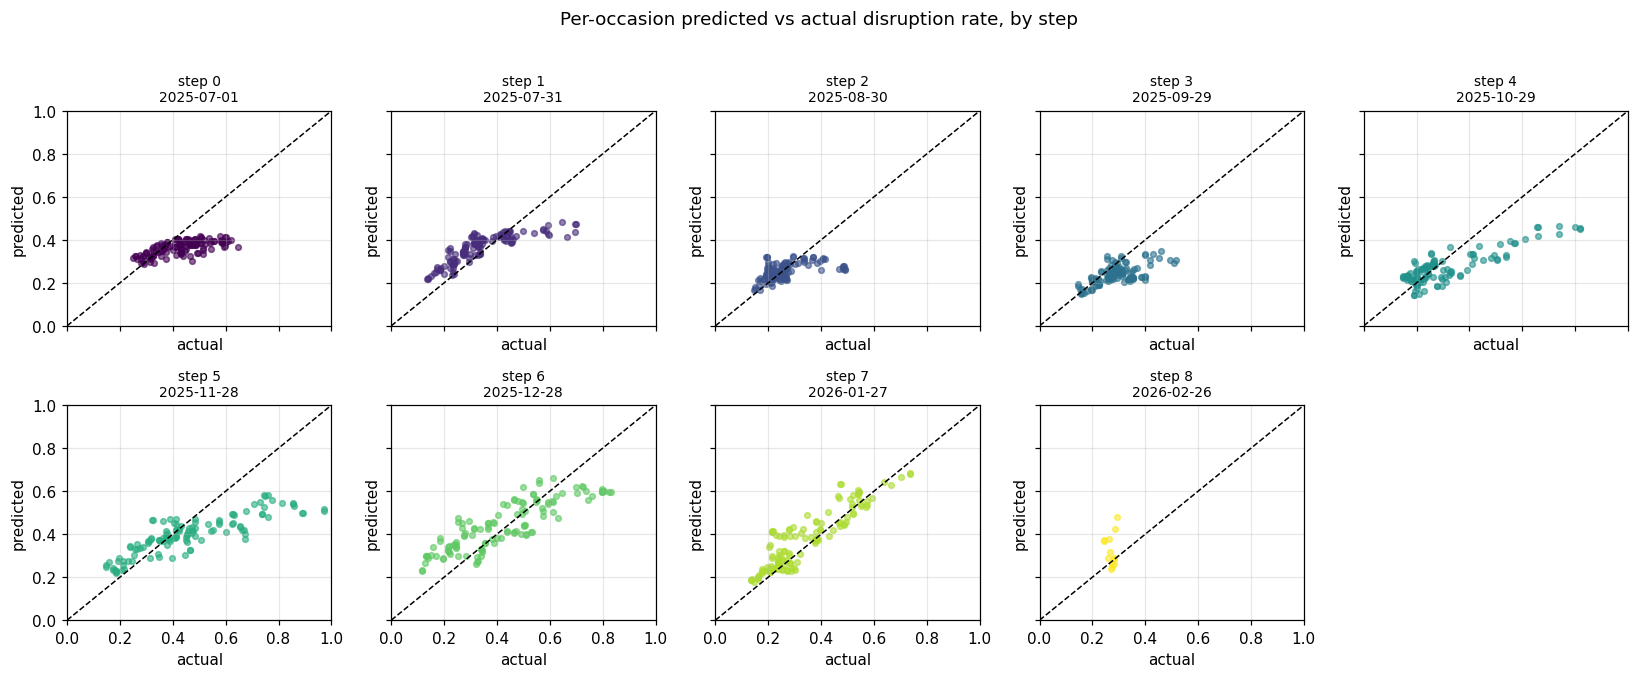

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
data = [OCC.loc[OCC["step"] == s, "abs_error"].to_numpy()
        for s in STEPS["step"]]
labels = [f"{int(r['step'])}\n{r['t_train_end'].date()}"
          for _, r in STEPS.iterrows()]
ax.boxplot(data, tick_labels=labels, showfliers=False, patch_artist=True,
            boxprops=dict(facecolor="#cce5ff", alpha=0.8))
ax.set_ylabel("|predicted rate - actual rate|  per 48h occasion")
ax.set_title("Per-occasion abs error distribution per step")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# Also the predicted vs actual scatter, faceted by step.
n_steps = len(STEPS)
n_cols = min(n_steps, 5)
n_rows = -(-n_steps // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows),
                          sharex=True, sharey=True, squeeze=False)
for ax, (_, row) in zip(axes.ravel(), STEPS.iterrows()):
    sub = OCC.loc[OCC["step"] == row["step"]]
    ax.scatter(sub["actual_rate"], sub["predicted_rate"], s=14, alpha=0.6,
                color=cmap(int(row["step"])))
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(f"step {int(row['step'])}\n{row['t_train_end'].date()}",
                  fontsize=9)
    ax.set_xlabel("actual"); ax.set_ylabel("predicted")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
for ax in axes.ravel()[len(STEPS):]:
    ax.axis("off")
fig.suptitle("Per-occasion predicted vs actual disruption rate, by step", y=1.02)
plt.tight_layout(); plt.show()


## 7. Lead-time stratified error within each step

The 48 h window in each occasion spans leads 0–48 h. For a sanity check
we bin per-flight predictions by their `lead_origin_h` and report Brier
per bin, per step.


In [7]:
flt = FLIGHT.copy()
flt["lead_bin"] = pd.cut(flt["lead_origin_h"],
                          bins=[0, 12, 24, 36, 48], right=False,
                          labels=["0-12h", "12-24h", "24-36h", "36-48h"])
def brier(g):
    return brier_score_loss(g["y_true"], g["p_hat"])
g = (flt.groupby(["step", "lead_bin"], observed=True)
        .apply(brier, include_groups=False)
        .unstack("lead_bin"))
g.index.name = "step"
g


lead_bin,0-12h,12-24h,24-36h,36-48h
step,,,,
0,0.2125,0.2142,0.2168,0.2155
1,0.1939,0.1939,0.1942,0.1933
2,0.1804,0.1794,0.1801,0.1785
3,0.1945,0.1953,0.1975,0.1979
4,0.1821,0.1858,0.1883,0.1904
5,0.2080,0.2142,0.2176,0.2203
6,0.1942,0.1974,0.1975,0.2005
7,0.1947,0.1972,0.1961,0.1964
8,0.1971,0.2039,0.2125,0.2073


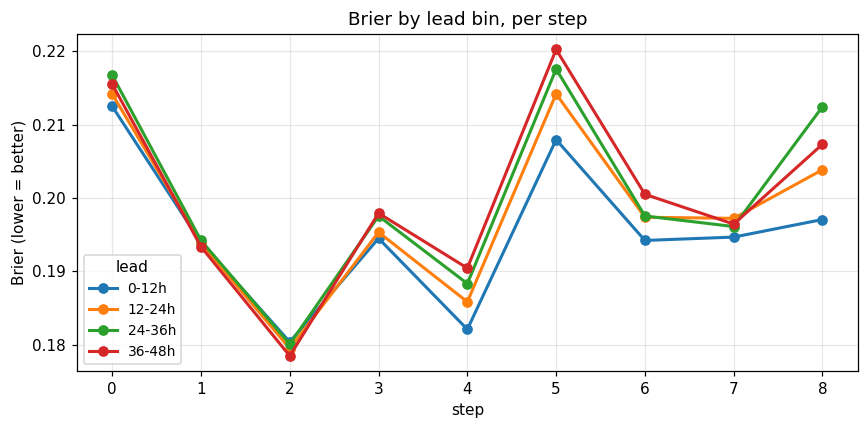

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for col in g.columns:
    ax.plot(g.index, g[col], "o-", label=col, lw=2)
ax.set_xlabel("step"); ax.set_ylabel("Brier (lower = better)")
ax.set_title("Brier by lead bin, per step")
ax.legend(title="lead", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


If Brier rises monotonically with lead bin in every step, that's the expected shape: the further out the forecast, the harder the prediction. If a particular step misbehaves at long lead, that's worth digging into.

## Takeaways

- **Did the expanding window pay off?** Compare the trajectory plots
  to the single-shot HistGBT reference line. If walk-forward LightGBM
  beats single-shot HistGBT on per-occasion MAE / Brier by a clear
  margin you can attribute lift to *retraining*; if not, the lift
  vs. single-shot is mostly *model class* (LightGBM vs. HistGBT) and
  arguably retraining isn't earning its keep.
- **Calibration drift** is the most operationally relevant signal —
  the bias trajectory tells you whether the model is keeping up with
  the regime, and the per-step calibration overlay shows where the
  curves sit in absolute terms. Persistent negative bias after several
  retrains is the cue that you need post-hoc isotonic recalibration
  on top of the model, not just another retrain.
- **Cadence sweep**: re-run with
  `--retrain-every-days 7` (weekly) or `--retrain-every-days 14`
  (biweekly) to see whether more frequent retrains help. Marginal
  returns usually decay quickly past weekly retraining for
  hourly-resolution flight data.
